In [ ]:
!pip install -Uq pymcel rebound

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 833.3/833.3 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 25.3 MB/s eta 0:00:00


In [1]:
import numpy as np
import pymcel as pc
import rebound as rb
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import spiceypy as spy

deg = np.pi/180
rad = 1/deg

Bienvenido a PyMCel v0.9.21 ¡al infinito y más allá!


## Ejercicio 8.12

In [2]:
mu_earth = pc.constantes.GM_earth
mu_sun = pc.constantes.GM_sun
mu_jup = pc.constantes.GM_jup
R_earth = 149.6e6 * 1e3  # In m
R_jup = 778.6e6 * 1e3
r_jup = pc.constantes.R_jup
rp = 200000e3 + r_jup

In [3]:
# Unit vectors
u_v = np.array([1.0, 0.0])
u_s = np.array([0.0, 1.0])

The semimajor axis of the initial orbit is found, and from it the first velocity and the hyperbolic excess velocity are calculated.

In [4]:
a1 = (1 / 2) * (R_earth + R_jup)

In [5]:
v_jup = np.sqrt(mu_sun / R_jup)
v1_v = np.sqrt(mu_sun * (2/R_jup - 1/a1))

v_inf_vec = v_jup * u_v - v1_v*u_v
v_inf = v_jup - v1_v

Then the eccentricity, $\delta$, and $\phi_2$ are calculated.

In [6]:
e = 1 + (rp * v_inf**2 / mu_jup)

In [7]:
delta_s = 2 * np.arcsin(1 / e)
phi2 = np.pi - delta_s
np.rad2deg(phi2)

np.float64(41.182676875786775)

The unit vectors are defined to calculate velocity 2 and the delta-v.

In [8]:
# Velocity 2 and delta-v
v2_v = v_jup * u_v + (v_inf * np.cos(phi2) * u_v + v_inf * np.sin(phi2) * u_s)
v2_v_mag = np.linalg.norm(v2_v)

deltav_v = v2_v - v1_v * u_v
deltav_v_mag = 2 * v_inf * np.sin(delta_s / 2)

v2_v_mag, deltav_v_mag

(np.float64(17697.351344119863), np.float64(10565.449763192488))

Using this, the angular momentum, the semimajor axis of the final orbit, and its eccentricity are calculated.

+ It is obtained from the energy equation.

In [9]:
h2 = R_jup * v2_v[0]
a2 = (-mu_sun)/ (2*((v2_v_mag**2 / 2) - (mu_sun / R_jup)))
a2

np.float64(4790382268118.731)

+ It is obtained from the semimajor-axis equation for Hohmann transfers.

In [10]:
e2 = np.sqrt(1 - (h2**2 / (a2 * mu_sun)))

+ It is obtained from the radius equation.

In [11]:
theta2 = np.arccos((h2**2/(mu_sun*R_jup) - 1) / e2)
np.rad2deg(theta2)

np.float64(26.503128250231526)

In [12]:
print(f"The magnitude of Delta V is {deltav_v_mag/1e3:.1f} km/s")
print(f"The semimajor axis of the new orbit is {a2/1e3:.2f} km")
print(f"The eccentricity is {e2:.4f}")
print(f"The angle theta is equal to {np.rad2deg(theta2):.1f}°")

The magnitude of Delta V is 10.6 km/s
The semimajor axis of the new orbit is 4790382268.12 km
The eccentricity is 0.8453
The angle theta is equal to 26.5°


## Plot

In [13]:
zetas = np.linspace(0.1, 1, 10)
es = np.linspace(0.01, 0.99, 10)

In [14]:
es_grid = es[:, np.newaxis]
zetas_grid = zetas[np.newaxis, :]

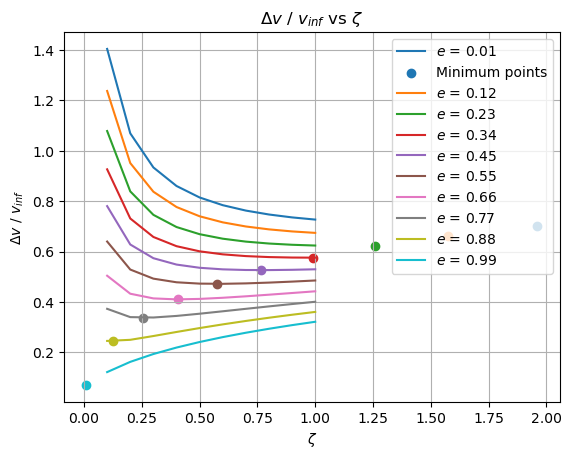

In [15]:
pio.renderers.default = "png"


dv_vinf = np.sqrt(1 + 2 / zetas_grid) - np.sqrt((1 + es_grid) / zetas_grid)
zeta_min = 2 * (1 - es_grid) / (1 + es_grid)
dv_vinf_zm = np.sqrt(1 + 2 / zeta_min) - np.sqrt((1 + es_grid) / zeta_min)

for i, e in enumerate(es):
  plt.plot(zetas, dv_vinf[i], label=f'$e$ = {e:.2f}')
  plt.scatter(zeta_min[i], dv_vinf_zm[i], marker='o', label = 'Minimum points' if i == 0 else "")

plt.xlabel(r'$\zeta$')
plt.ylabel (r'$\Delta v$ / $v_{inf}$')
plt.title(r'$\Delta v$ / $v_{inf}$ vs $\zeta$')
plt.legend()
plt.grid(True)
plt.show()